# 05 — Evaluation

First and only touch of the held-out test seasons (2024/25 onward). Train on all dev seasons at the tuned `(L, ALPHA, xgb_params)`; score once on test.

Derived markets (1X2, BTTS, O/U) are reductions of the 11×11 scoreline matrix `scoreline_matrix(lh, la)`.

## 1. Imports & Config

In [39]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import poisson
from collections import defaultdict
from pathlib import Path
import math, json, random, datetime, itertools

pd.set_option('display.max_columns', None)

RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Brand palette: Green → Yellow → Purple → Red
COLOURS = ['#027B5B', '#F9DC1C', '#54008B', '#D20F2D']

DATA_PATH = Path('../Outputs/Cleaning/df_cleaned.csv')
FEAT_DIR  = Path('../Outputs/Features')
TUNE_DIR  = Path('../Outputs/Tuning')
EVAL_DIR  = Path('../Outputs/Evaluation'); EVAL_DIR.mkdir(parents=True, exist_ok=True)

MAX_GOALS_PER_TEAM = 10
TOTAL_GOALS_CAP    = 8
GOAL_BUCKETS       = list(range(TOTAL_GOALS_CAP)) + ['8+']
LEAGUE_RANK        = {'Premier League': 2, 'Championship': 1, 'League One': 0}
TEST_SEASON        = '2024/2025'

OU_LINES = [0.5, 1.5, 2.5, 3.5]
MARKET_KEYS = ['1X2', 'BTTS', 'O/U 0.5', 'O/U 1.5', 'O/U 2.5', 'O/U 3.5', 'Total Goals']

## 2. Load NB04 Outputs

In [40]:
tuned = json.loads((TUNE_DIR / 'tuning_best.json').read_text())

SELECTED_FEATS   = tuned['selected_features']
BEST_L           = int(tuned['best_L'])
BEST_ALPHA       = float(tuned['best_ALPHA'])
BEST_XGB_PARAMS  = dict(tuned['best_xgb_params']); BEST_XGB_PARAMS['random_state'] = RANDOM_SEED
NB04_VAL_LOGLOSS = float(tuned['final_validation_logloss'])
NB04_VAL_STD     = float(tuned.get('final_validation_std', float('nan')))

assert len(SELECTED_FEATS) > 0
assert len(set(SELECTED_FEATS)) == len(SELECTED_FEATS)

print(f'Selected features ({len(SELECTED_FEATS)}): {SELECTED_FEATS}')
print(f'Tuned (L, ALPHA)        : ({BEST_L}, {BEST_ALPHA})')
print(f'NB04 dev-val logloss    : {NB04_VAL_LOGLOSS:.6f} (±{NB04_VAL_STD:.6f})')
print(f'XGB params              : {json.dumps(BEST_XGB_PARAMS, indent=2)}')

Selected features (5): ['team_avg_gls_f_v', 'team_avg_xg_f', 'team_avg_xg_c', 'opp_avg_xg_c', 'game_week_normalised']
Tuned (L, ALPHA)        : (40, 0.05)
NB04 dev-val logloss    : 1.840344 (±0.010204)
XGB params              : {
  "colsample_bytree": 0.6,
  "enable_categorical": true,
  "learning_rate": 0.01,
  "max_depth": 3,
  "min_child_weight": 5,
  "n_estimators": 400,
  "objective": "count:poisson",
  "random_state": 2026,
  "reg_alpha": 1,
  "reg_lambda": 0.1,
  "subsample": 0.5,
  "verbosity": 0
}


## 3. Rebuild Features at Tuned `(L, ALPHA)`

Leakage contract: trained only on seasons `< 2024/2025`; seasons `>= 2024/2025` scored once with no tuning here.

In [41]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)
df = df_raw.copy()

home_map = df[['home_team', 'season', 'league']].rename(columns={'home_team': 'team'})
away_map = df[['away_team', 'season', 'league']].rename(columns={'away_team': 'team'})
team_season_league = (pd.concat([home_map, away_map]).drop_duplicates()
                       .sort_values(['team', 'season']).reset_index(drop=True))
team_season_league['prev_league'] = team_season_league.groupby('team')['league'].shift(1)
team_season_league['curr_rank']   = team_season_league['league'].map(LEAGUE_RANK)
team_season_league['prev_rank']   = team_season_league['prev_league'].map(LEAGUE_RANK)
team_season_league['promoted_flag']  = ((team_season_league['curr_rank'] > team_season_league['prev_rank']).fillna(False).astype(int))
team_season_league['relegated_flag'] = ((team_season_league['curr_rank'] < team_season_league['prev_rank']).fillna(False).astype(int))
flag_lookup = team_season_league.set_index(['team', 'season'])[['promoted_flag', 'relegated_flag']]

for side in ['home', 'away']:
    team_col = f'{side}_team'
    merged = df[[team_col, 'season']].merge(
        flag_lookup.rename(columns={'promoted_flag': f'{side}_promoted_flag',
                                    'relegated_flag': f'{side}_relegated_flag'}),
        left_on=[team_col, 'season'], right_index=True, how='left')
    df[f'{side}_promoted_flag']  = merged[f'{side}_promoted_flag'].fillna(0).astype(int).values
    df[f'{side}_relegated_flag'] = merged[f'{side}_relegated_flag'].fillna(0).astype(int).values

df = df[~(df['home_xg'].isna() | df['away_xg'].isna())].reset_index(drop=True)
df['total_goals'] = df['home_goals'] + df['away_goals']
print(f'After xG drop: {len(df):,} rows  ({df["date"].min().date()} → {df["date"].max().date()})')

seasons_sorted = sorted(df['season'].unique())
l1_seeds = {}
for i, season in enumerate(seasons_sorted):
    if i == 0:
        continue
    prev = seasons_sorted[i - 1]
    sub  = df[(df['season'] == prev) & (df['league'] == 'League One')]
    if sub.empty:
        continue
    per_team_goals = (sub['home_goals'] + sub['away_goals']).mean() / 2.0
    per_team_xg    = (sub['home_xg']    + sub['away_xg']).mean()    / 2.0
    l1_seeds[season] = {'gls_f': per_team_goals, 'gls_c': per_team_goals,
                        'xg_f':  per_team_xg,    'xg_c':  per_team_xg}

After xG drop: 10,687 rows  (2018-08-03 → 2026-02-16)


In [42]:
FEATURE_SPEC = {
    'team_avg_gls_f':   {'scope': 'team', 'side': 'f', 'stat': 'gls', 'venue': 'all'},
    'team_avg_gls_c':   {'scope': 'team', 'side': 'c', 'stat': 'gls', 'venue': 'all'},
    'team_avg_xg_f':    {'scope': 'team', 'side': 'f', 'stat': 'xg',  'venue': 'all'},
    'team_avg_xg_c':    {'scope': 'team', 'side': 'c', 'stat': 'xg',  'venue': 'all'},
    'team_avg_gls_f_v': {'scope': 'team', 'side': 'f', 'stat': 'gls', 'venue': 'venue'},
    'team_avg_gls_c_v': {'scope': 'team', 'side': 'c', 'stat': 'gls', 'venue': 'venue'},
    'team_avg_xg_f_v':  {'scope': 'team', 'side': 'f', 'stat': 'xg',  'venue': 'venue'},
    'team_avg_xg_c_v':  {'scope': 'team', 'side': 'c', 'stat': 'xg',  'venue': 'venue'},
    'opp_avg_gls_f':    {'scope': 'opp',  'side': 'f', 'stat': 'gls', 'venue': 'all'},
    'opp_avg_gls_c':    {'scope': 'opp',  'side': 'c', 'stat': 'gls', 'venue': 'all'},
    'opp_avg_xg_f':     {'scope': 'opp',  'side': 'f', 'stat': 'xg',  'venue': 'all'},
    'opp_avg_xg_c':     {'scope': 'opp',  'side': 'c', 'stat': 'xg',  'venue': 'all'},
    'opp_avg_gls_f_v':  {'scope': 'opp',  'side': 'f', 'stat': 'gls', 'venue': 'venue'},
    'opp_avg_gls_c_v':  {'scope': 'opp',  'side': 'c', 'stat': 'gls', 'venue': 'venue'},
    'opp_avg_xg_f_v':   {'scope': 'opp',  'side': 'f', 'stat': 'xg',  'venue': 'venue'},
    'opp_avg_xg_c_v':   {'scope': 'opp',  'side': 'c', 'stat': 'xg',  'venue': 'venue'},
    'league_avg_vgf':   {'scope': 'league', 'vgf': True},
    'league_avg_vgc':   {'scope': 'league', 'vgf': False},
    'is_crowds':             {'scope': 'context', 'col': 'is_crowds'},
    'game_week_normalised':  {'scope': 'context', 'col': 'game_week_normalised'},
    'league':                {'scope': 'context', 'col': 'league'},
    'is_home':               {'scope': 'context', 'col': None},
    'team_promoted_flag':  {'scope': 'movement', 'home_col': 'home_promoted_flag',  'away_col': 'away_promoted_flag'},
    'team_relegated_flag': {'scope': 'movement', 'home_col': 'home_relegated_flag', 'away_col': 'away_relegated_flag'},
    'opp_promoted_flag':   {'scope': 'movement', 'home_col': 'away_promoted_flag',  'away_col': 'home_promoted_flag'},
    'opp_relegated_flag':  {'scope': 'movement', 'home_col': 'away_relegated_flag', 'away_col': 'home_relegated_flag'},
}
for f in SELECTED_FEATS:
    assert f in FEATURE_SPEC, f'no spec for {f!r}'

max_gw = df.groupby(['league', 'season'])['game_week'].max().to_dict()

def _stat_key(stat, side):
    return f'{stat}_{side}'

def _weighted_mean(buf, window, alpha):
    recent = buf[-window:]
    k = len(recent)
    if k == 0:
        return np.nan
    w = np.exp(-alpha * (k - 1 - np.arange(k)))
    w = w / w.sum()
    return float(np.dot(w, recent))

In [43]:
def build_features_tuned(L, ALPHA):
    L = int(L); ALPHA = float(ALPHA)
    L_V = math.ceil(0.5 * L)
    rolling_feats = [f for f in SELECTED_FEATS if FEATURE_SPEC[f]['scope'] in ('team', 'opp')]
    needed_keys = sorted({_stat_key(FEATURE_SPEC[f]['stat'], FEATURE_SPEC[f]['side']) for f in rolling_feats})
    _needs_league = any(FEATURE_SPEC[f]['scope'] == 'league' for f in SELECTED_FEATS)
    league_buffer = defaultdict(list)
    team_gen  = defaultdict(lambda: defaultdict(list))
    team_home = defaultdict(lambda: defaultdict(list))
    team_away = defaultdict(lambda: defaultdict(list))
    team_home_count = defaultdict(int)
    team_away_count = defaultdict(int)
    feature_rows = []
    for match_id, row in df.iterrows():
        league = row['league']; season = row['season']; date = row['date']
        ht = row['home_team']; at = row['away_team']
        hg, ag   = row['home_goals'], row['away_goals']
        hxg, axg = row['home_xg'],    row['away_xg']
        gw       = row['game_week']
        match_tg = hg + ag
        seed = l1_seeds.get(season) if league == 'League One' else None
        nh_h, na_h = team_home_count[ht], team_away_count[ht]
        nh_a, na_a = team_home_count[at], team_away_count[at]
        wide = {
            'match_id': match_id, 'date': date, 'season': season, 'league': league,
            'game_week': gw, 'home_team': ht, 'away_team': at,
            'home_goals': hg, 'away_goals': ag, 'total_goals': match_tg,
            'is_crowds':             row['is_crowds'],
            'game_week_normalised':  gw / max_gw.get((league, season), gw),
            'home_promoted_flag':    row['home_promoted_flag'],
            'away_promoted_flag':    row['away_promoted_flag'],
            'home_relegated_flag':   row['home_relegated_flag'],
            'away_relegated_flag':   row['away_relegated_flag'],
        }
        if _needs_league:
            buf_filtered = [(s, g, h, a) for (s, g, h, a) in league_buffer[league] if (s, g) != (season, gw)][-L:]
            if buf_filtered:
                wide['league_avg_hg'] = float(np.mean([h for _, _, h, _ in buf_filtered]))
                wide['league_avg_ag'] = float(np.mean([a for _, _, _, a in buf_filtered]))
            else:
                wide['league_avg_hg'] = np.nan
                wide['league_avg_ag'] = np.nan
        def _read(side_is_home, feat_name):
            spec = FEATURE_SPEC[feat_name]; sc = spec['scope']
            if sc in ('team', 'opp'):
                stat_key = _stat_key(spec['stat'], spec['side'])
                if sc == 'team':
                    t = ht if side_is_home else at
                    nh, na = (nh_h, na_h) if side_is_home else (nh_a, na_a)
                    use_home_buf = side_is_home
                else:
                    t = at if side_is_home else ht
                    nh, na = (nh_a, na_a) if side_is_home else (nh_h, na_h)
                    use_home_buf = not side_is_home
                if (nh < 1) or (na < 1):
                    return float(seed[stat_key]) if seed is not None else np.nan
                if spec['venue'] == 'all':
                    return _weighted_mean(team_gen[t][stat_key], L, ALPHA)
                buf = team_home[t][stat_key] if use_home_buf else team_away[t][stat_key]
                return _weighted_mean(buf, L_V, ALPHA)
            elif sc == 'league':
                hg_val = wide.get('league_avg_hg', np.nan)
                ag_val = wide.get('league_avg_ag', np.nan)
                return hg_val if (side_is_home == spec['vgf']) else ag_val
            elif sc == 'context':
                if spec['col'] is None:
                    return int(side_is_home)
                return wide.get(spec['col'], np.nan)
            elif sc == 'movement':
                col = spec['home_col'] if side_is_home else spec['away_col']
                return float(wide.get(col, 0))
            return np.nan
        for feat in rolling_feats:
            wide[f'home_{feat}'] = _read(True,  feat)
            wide[f'away_{feat}'] = _read(False, feat)
        feature_rows.append(wide)
        h_obs = {'gls_f': hg, 'gls_c': ag, 'xg_f': hxg, 'xg_c': axg}
        a_obs = {'gls_f': ag, 'gls_c': hg, 'xg_f': axg, 'xg_c': hxg}
        for k in needed_keys:
            team_gen[ht][k].append(h_obs[k]); team_gen[at][k].append(a_obs[k])
            team_home[ht][k].append(h_obs[k]); team_away[at][k].append(a_obs[k])
        team_home_count[ht] += 1; team_away_count[at] += 1
        if _needs_league:
            league_buffer[league].append((season, gw, hg, ag))
    df_wide = pd.DataFrame(feature_rows)
    rolling_side_cols = [f'{p}_{f}' for p in ('home', 'away') for f in rolling_feats]
    if rolling_side_cols:
        df_wide = df_wide[~df_wide[rolling_side_cols].isna().any(axis=1)].reset_index(drop=True)
    season_dtype = pd.CategoricalDtype(categories=sorted(df_wide['season'].unique()), ordered=True)
    df_wide['season'] = df_wide['season'].astype(season_dtype)
    df_wide['league'] = df_wide['league'].astype('category')
    def _side_long(is_home):
        prefix = 'home' if is_home else 'away'; opp_prefix = 'away' if is_home else 'home'
        out = pd.DataFrame({
            'match_id': df_wide['match_id'].values, 'date': df_wide['date'].values,
            'season':   df_wide['season'].values,   'league': df_wide['league'].values,
            'team':     df_wide[f'{prefix}_team'].values,
            'opponent': df_wide[f'{opp_prefix}_team'].values,
            'is_home':  int(is_home),
            'team_goals':  df_wide[f'{prefix}_goals'].values,
            'total_goals': df_wide['total_goals'].values,
        })
        for f in SELECTED_FEATS:
            spec = FEATURE_SPEC[f]; sc = spec['scope']
            if sc in ('team', 'opp'):
                out[f] = df_wide[f'{prefix}_{f}'].values
            elif sc == 'league':
                hg = df_wide['league_avg_hg'].values; ag = df_wide['league_avg_ag'].values
                out[f] = hg if (is_home == spec['vgf']) else ag
            elif sc == 'context':
                if spec['col'] is None:
                    out[f] = int(is_home)
                else:
                    out[f] = df_wide[spec['col']].values
            elif sc == 'movement':
                col = spec['home_col'] if is_home else spec['away_col']
                out[f] = df_wide[col].values
        return out
    df_long = pd.concat([_side_long(True), _side_long(False)], ignore_index=True)
    df_long['season'] = df_long['season'].astype(season_dtype)
    df_long['league'] = df_long['league'].astype('category')
    df_long = df_long.sort_values(['date', 'match_id', 'is_home'], ascending=[True, True, False]).reset_index(drop=True)
    return df_wide, df_long

df_wide, df_long = build_features_tuned(BEST_L, BEST_ALPHA)
print(f'Wide: {df_wide.shape[0]:,} matches  Long: {df_long.shape[0]:,} rows')

df_wide_test = df_wide[df_wide['season'] >= TEST_SEASON].copy()
df_long_test = df_long[df_long['season'] >= TEST_SEASON].copy()
print(f'Test set >= {TEST_SEASON}: {len(df_wide_test):,} fixtures')

Wide: 10,610 matches  Long: 21,220 rows
Test set >= 2024/2025: 2,488 fixtures


In [44]:
def _spot_check_leakage():
    rolling_all = [f for f in SELECTED_FEATS
                   if FEATURE_SPEC[f]['scope'] == 'team' and FEATURE_SPEC[f].get('venue') == 'all']
    if not rolling_all:
        print('Leakage spot check: no team+all-venue feature selected — skipped.')
        return
    feat = rolling_all[0]; spec = FEATURE_SPEC[feat]
    candidate = df_wide.iloc[len(df_wide) // 2]
    mid = candidate['match_id']; team = candidate['home_team']; date = candidate['date']
    prior_rows = df[(df['date'] < date) & ((df['home_team'] == team) | (df['away_team'] == team))].sort_values('date')
    obs = []
    for _, r in prior_rows.iterrows():
        is_home = (r['home_team'] == team)
        gf = r['home_goals'] if is_home else r['away_goals']
        gc = r['away_goals'] if is_home else r['home_goals']
        xf = r['home_xg']    if is_home else r['away_xg']
        xc = r['away_xg']    if is_home else r['home_xg']
        obs.append({'gls_f': gf, 'gls_c': gc, 'xg_f': xf, 'xg_c': xc}[_stat_key(spec['stat'], spec['side'])])
    expected = _weighted_mean(obs, BEST_L, BEST_ALPHA)
    actual   = candidate[f'home_{feat}']
    ok = np.isclose(expected, actual, atol=1e-9, equal_nan=True)
    print(f'Leakage spot check ({feat}, match {mid}): expected={expected:.6f}  actual={actual:.6f}  -> {"OK" if ok else "MISMATCH"}')
    assert ok
_spot_check_leakage()

Leakage spot check (team_avg_xg_f, match 5382): expected=0.890862  actual=0.890862  -> OK


## 4. Final Fit → Predict on Test

In [45]:
def team_pmf(lmbda, max_goals=MAX_GOALS_PER_TEAM):
    ks = np.arange(max_goals + 1)
    p = poisson.pmf(ks, lmbda).astype(float)
    p[-1] += poisson.sf(max_goals, lmbda)
    return p

def scoreline_matrix(lambda_home, lambda_away, max_goals=MAX_GOALS_PER_TEAM):
    return np.outer(team_pmf(lambda_home, max_goals), team_pmf(lambda_away, max_goals))

def total_goals_pmf_from_matrix(M, cap=TOTAL_GOALS_CAP):
    n = M.shape[0]
    totals = np.zeros(2 * (n - 1) + 1)
    for i in range(n):
        for j in range(n):
            totals[i + j] += M[i, j]
    out = np.zeros(cap + 1)
    out[:cap] = totals[:cap]
    out[cap]  = totals[cap:].sum()
    return out

def total_goals_pmf_from_lambda(lmbda, cap=TOTAL_GOALS_CAP):
    ks  = np.arange(cap)
    out = np.zeros(cap + 1)
    out[:cap] = poisson.pmf(ks, lmbda)
    out[cap]  = poisson.sf(cap - 1, lmbda)
    return out

def _check_pmf(pmf):
    assert len(pmf) == len(GOAL_BUCKETS)
    assert np.isclose(pmf.sum(), 1.0, atol=1e-6)
    return pmf

def total_goals_logloss(pmf, actual_total, cap=TOTAL_GOALS_CAP, eps=1e-15):
    return -np.log(max(pmf[min(int(actual_total), cap)], eps))

def bucket_actual(actual_total, cap=TOTAL_GOALS_CAP):
    return min(int(actual_total), cap)

def run_xgb_selected(dev_long, val_seasons, params, feats=None, label='XGB'):
    if feats is None:
        feats = SELECTED_FEATS
    recs = []
    for vs in val_seasons:
        train = dev_long[dev_long['season'] < vs]
        val   = dev_long[dev_long['season'] == vs]
        if train.empty or val.empty:
            continue
        valid_leagues = set(train['league'].unique())
        val = val[val['league'].isin(valid_leagues)].copy()
        if val.empty:
            continue
        model = xgb.XGBRegressor(**params)
        model.fit(train[feats], train['team_goals'])
        val['lam'] = np.clip(model.predict(val[feats]), 1e-8, None)
        for mid, grp in val.groupby('match_id'):
            home = grp[grp['is_home'] == 1]; away = grp[grp['is_home'] == 0]
            if len(home) != 1 or len(away) != 1:
                continue
            lh = float(home['lam'].iloc[0]); la = float(away['lam'].iloc[0])
            pmf = _check_pmf(total_goals_pmf_from_matrix(scoreline_matrix(lh, la)))
            recs.append({
                'model': label, 'val_season': vs, 'match_id': mid,
                'league': home['league'].iloc[0],
                'total_goals': int(home['total_goals'].iloc[0]),
                'expected': lh + la, 'pmf': pmf,
                'lambda_home': lh, 'lambda_away': la,
            })
    return pd.DataFrame(recs)

def run_baseline_selected(dev_wide, val_seasons):
    recs = []
    for vs in val_seasons:
        train = dev_wide[dev_wide['season'] < vs]
        val   = dev_wide[dev_wide['season'] == vs]
        if train.empty or val.empty:
            continue
        lambda_map = train.groupby('league', observed=True)['total_goals'].mean().to_dict()
        val = val[val['league'].isin(lambda_map.keys())]
        for _, r in val.iterrows():
            lam = float(lambda_map[r['league']])
            pmf = _check_pmf(total_goals_pmf_from_lambda(lam))
            recs.append({'model': 'Baseline', 'val_season': vs, 'match_id': r['match_id'],
                         'league': r['league'], 'total_goals': int(r['total_goals']),
                         'expected': lam, 'pmf': pmf,
                         'lambda_home': np.nan, 'lambda_away': np.nan})
    return pd.DataFrame(recs)

def fit_predict_test_xgb(df_long, test_cutoff, params, feats=None, label='Tuned_XGB'):
    """Train once on seasons < cutoff; score every fixture in seasons >= cutoff."""
    if feats is None:
        feats = SELECTED_FEATS
    train = df_long[df_long['season'] <  test_cutoff]
    test  = df_long[df_long['season'] >= test_cutoff].copy()
    test  = test[test['league'].isin(set(train['league'].unique()))].copy()
    model = xgb.XGBRegressor(**params)
    model.fit(train[feats], train['team_goals'])
    test['lam'] = np.clip(model.predict(test[feats]), 1e-8, None)
    recs = []
    for mid, grp in test.groupby('match_id'):
        home = grp[grp['is_home'] == 1]; away = grp[grp['is_home'] == 0]
        if len(home) != 1 or len(away) != 1:
            continue
        lh = float(home['lam'].iloc[0]); la = float(away['lam'].iloc[0])
        pmf = _check_pmf(total_goals_pmf_from_matrix(scoreline_matrix(lh, la)))
        recs.append({
            'model': label, 'season': home['season'].iloc[0], 'match_id': mid,
            'league': home['league'].iloc[0],
            'total_goals': int(home['total_goals'].iloc[0]),
            'expected': lh + la, 'pmf': pmf,
            'lambda_home': lh, 'lambda_away': la,
        })
    return pd.DataFrame(recs)

def fit_predict_test_baseline(df_wide, test_cutoff):
    """League-mean lambda from dev (< cutoff); score every fixture >= cutoff."""
    train = df_wide[df_wide['season'] <  test_cutoff]
    test  = df_wide[df_wide['season'] >= test_cutoff]
    lambda_map = train.groupby('league', observed=True)['total_goals'].mean().to_dict()
    test = test[test['league'].isin(lambda_map.keys())]
    recs = []
    for _, r in test.iterrows():
        lam = float(lambda_map[r['league']])
        pmf = _check_pmf(total_goals_pmf_from_lambda(lam))
        recs.append({'model': 'Baseline', 'season': r['season'], 'match_id': r['match_id'],
                     'league': r['league'], 'total_goals': int(r['total_goals']),
                     'expected': lam, 'pmf': pmf,
                     'lambda_home': np.nan, 'lambda_away': np.nan})
    return pd.DataFrame(recs)

preds_model    = fit_predict_test_xgb(df_long, TEST_SEASON, BEST_XGB_PARAMS, label='Tuned_XGB')
preds_baseline = fit_predict_test_baseline(df_wide, TEST_SEASON)

common = set(preds_model['match_id']) & set(preds_baseline['match_id'])
preds_model    = preds_model[preds_model['match_id'].isin(common)].reset_index(drop=True)
preds_baseline = preds_baseline[preds_baseline['match_id'].isin(common)].reset_index(drop=True)
print(f'Test fixtures scored by both: {len(common):,}')

Test fixtures scored by both: 2,488


## 5. Derived-Market Engine

Every market is a reduction of the 11×11 scoreline matrix `M = scoreline_matrix(lh, la)`.

In [46]:
def market_probs_from_matrix(M):
    n = M.shape[0]
    iu = np.triu_indices(n, k=1); il = np.tril_indices(n, k=-1)
    p_away = float(M[iu].sum())   # away wins when away goals (col j) > home goals (row i)
    p_home = float(M[il].sum())
    p_draw = float(np.trace(M))
    p_btts_yes = float(M[1:, 1:].sum())
    tg_pmf = _check_pmf(total_goals_pmf_from_matrix(M))
    over = {}
    for line in OU_LINES:
        k = int(line)
        over[line] = float(1.0 - tg_pmf[:k + 1].sum())
    return {
        'p_home': p_home, 'p_draw': p_draw, 'p_away': p_away,
        'p_btts_yes': p_btts_yes, 'p_btts_no': 1.0 - p_btts_yes,
        'p_over_05': over[0.5], 'p_over_15': over[1.5],
        'p_over_25': over[2.5], 'p_over_35': over[3.5],
        'tg_pmf': tg_pmf,
    }

def market_probs_from_total_pmf(tg_pmf):
    over = {}
    for line in OU_LINES:
        k = int(line)
        over[line] = float(1.0 - tg_pmf[:k + 1].sum())
    return {
        'p_over_05': over[0.5], 'p_over_15': over[1.5],
        'p_over_25': over[2.5], 'p_over_35': over[3.5],
        'tg_pmf': tg_pmf,
    }

actuals = df_wide_test.set_index('match_id')[['home_goals', 'away_goals', 'total_goals', 'league', 'season', 'date', 'home_team', 'away_team']].copy()
actuals['actual_result'] = np.where(actuals['home_goals'] > actuals['away_goals'], 'H',
                            np.where(actuals['home_goals'] < actuals['away_goals'], 'A', 'D'))
actuals['actual_btts'] = ((actuals['home_goals'] >= 1) & (actuals['away_goals'] >= 1)).astype(int)
for line in OU_LINES:
    actuals[f'actual_over_{int(line*10):02d}'] = (actuals['total_goals'] > line).astype(int)

def _attach_markets(preds, has_matrix):
    rows = []
    for _, r in preds.iterrows():
        if has_matrix:
            M = scoreline_matrix(r['lambda_home'], r['lambda_away'])
            mp = market_probs_from_matrix(M)
        else:
            mp = market_probs_from_total_pmf(r['pmf'])
            mp.update({'p_home': np.nan, 'p_draw': np.nan, 'p_away': np.nan,
                       'p_btts_yes': np.nan, 'p_btts_no': np.nan})
        rec = {**r.to_dict(), **mp}
        rows.append(rec)
    out = pd.DataFrame(rows)
    out = out.merge(actuals[['actual_result', 'actual_btts',
                              'actual_over_05', 'actual_over_15',
                              'actual_over_25', 'actual_over_35']],
                    left_on='match_id', right_index=True, how='left')
    return out

M_preds    = _attach_markets(preds_model,    has_matrix=True)
B_preds    = _attach_markets(preds_baseline, has_matrix=False)
print(f'Model preds rows: {len(M_preds):,}  Baseline preds rows: {len(B_preds):,}')

assert set(M_preds['season'].astype(str)) >= {'2024/2025', '2025/2026'}, \
    'Test set should cover 2024/25 onward, not a single season.'

Model preds rows: 2,488  Baseline preds rows: 2,488


## 6. Metrics Helpers

In [47]:
EPS = 1e-15

def _metrics_block(preds, model_name):
    ll   = preds.apply(lambda r: total_goals_logloss(r['pmf'], r['total_goals']), axis=1)
    mae  = float((preds['expected'] - preds['total_goals']).abs().mean())
    rmse = float(np.sqrt(((preds['expected'] - preds['total_goals'])**2).mean()))
    top1 = float(preds.apply(lambda r: int(np.argmax(r['pmf'])) == bucket_actual(r['total_goals']), axis=1).mean())
    w1   = float(preds.apply(lambda r: abs(int(np.argmax(r['pmf'])) - bucket_actual(r['total_goals'])) <= 1, axis=1).mean())
    return {
        'model': model_name, 'n_matches': len(preds),
        'logloss_mean': float(ll.mean()), 'logloss_std': float(ll.std()),
        'mae': mae, 'rmse': rmse,
        'top1_accuracy': top1, 'within_1_accuracy': w1,
    }

def binary_metrics(y_true, p_yes, name):
    y = np.asarray(y_true, dtype=float); p = np.clip(np.asarray(p_yes, dtype=float), EPS, 1 - EPS)
    logloss = float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())
    brier   = float(((p - y) ** 2).mean())
    acc     = float(((p >= 0.5).astype(int) == y.astype(int)).mean())
    try:
        from sklearn.metrics import roc_auc_score
        auc = float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else float('nan')
    except Exception:
        auc = float('nan')
    return {'market': name, 'logloss': logloss, 'brier': brier, 'accuracy': acc, 'auc': auc, 'n': int(len(y))}

def multiclass_metrics(y_true_idx, P, name, k=3):
    y = np.asarray(y_true_idx, dtype=int); P = np.clip(np.asarray(P, dtype=float), EPS, 1.0)
    logloss = float(-np.log(P[np.arange(len(y)), y]).mean())
    onehot = np.zeros_like(P); onehot[np.arange(len(y)), y] = 1.0
    brier = float(((P - onehot) ** 2).sum(axis=1).mean())
    acc   = float((P.argmax(axis=1) == y).mean())
    return {'market': name, 'logloss': logloss, 'brier': brier, 'accuracy': acc, 'auc': float('nan'), 'n': int(len(y))}

def reliability_bins(y_true, p, n_bins=10):
    y = np.asarray(y_true, dtype=float); p = np.asarray(p, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p, edges, right=False) - 1, 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        m = (idx == b)
        if not m.any():
            rows.append({'bin': b, 'lo': edges[b], 'hi': edges[b + 1], 'n': 0, 'pred_mean': np.nan, 'obs_freq': np.nan}); continue
        rows.append({'bin': b, 'lo': edges[b], 'hi': edges[b + 1],
                     'n': int(m.sum()), 'pred_mean': float(p[m].mean()), 'obs_freq': float(y[m].mean())})
    return pd.DataFrame(rows)

def ece(y_true, p, n_bins=10):
    bins = reliability_bins(y_true, p, n_bins)
    bins = bins[bins['n'] > 0]
    if bins.empty:
        return float('nan')
    w = bins['n'] / bins['n'].sum()
    return float((w * (bins['pred_mean'] - bins['obs_freq']).abs()).sum())

## 7. Headline — Total Goals on Test Set

In [48]:
tot_rows = [_metrics_block(B_preds, 'Baseline'),
            _metrics_block(M_preds, 'Tuned_XGB')]
total_goals_metrics = pd.DataFrame(tot_rows)
print(total_goals_metrics.to_string(index=False))

    model  n_matches  logloss_mean  logloss_std      mae     rmse  top1_accuracy  within_1_accuracy
 Baseline       2488      1.828986     0.602438 1.256181 1.567301       0.243167           0.673232
Tuned_XGB       2488      1.825755     0.600065 1.254465 1.562557       0.240354           0.677653


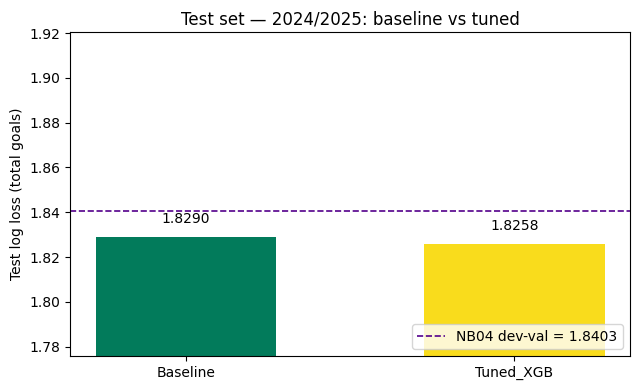

In [49]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
vals = total_goals_metrics['logloss_mean'].values
names = total_goals_metrics['model'].values
bars = ax.bar(names, vals, color=[COLOURS[0], COLOURS[1]], width=0.55)
ax.axhline(NB04_VAL_LOGLOSS, color=COLOURS[2], ls='--', lw=1.2,
           label=f'NB04 dev-val = {NB04_VAL_LOGLOSS:.4f}')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}', ha='center', va='bottom')
ax.set_ylabel('Test log loss (total goals)')
ax.set_title(f'Test set — {TEST_SEASON}: baseline vs tuned')
ax.legend(loc='lower right')
ax.set_ylim(min(vals.min(), NB04_VAL_LOGLOSS) - 0.05, max(vals.max(), NB04_VAL_LOGLOSS) + 0.08)
plt.tight_layout()
fig_logloss = fig
plt.show()

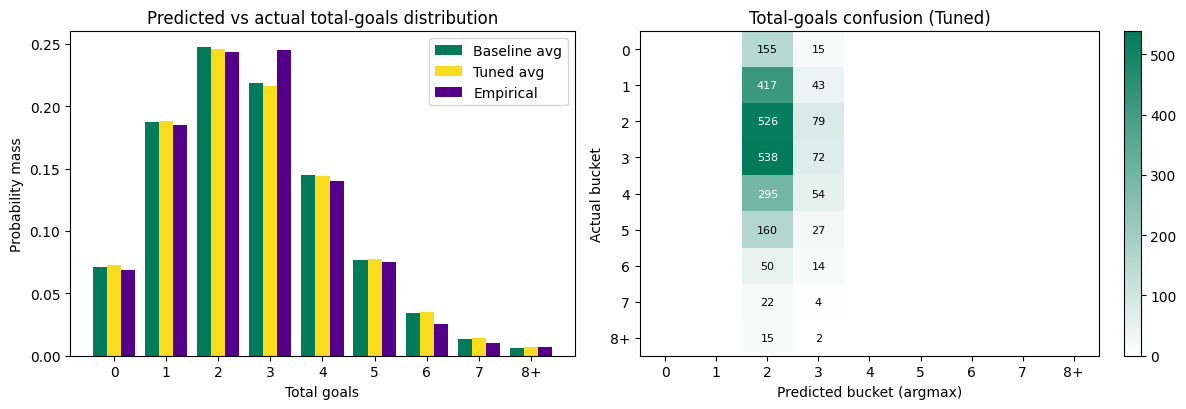

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

model_avg_pmf = np.vstack(M_preds['pmf'].values).mean(axis=0)
base_avg_pmf  = np.vstack(B_preds['pmf'].values).mean(axis=0)
emp = np.bincount(M_preds['total_goals'].apply(bucket_actual).values, minlength=len(GOAL_BUCKETS)) / len(M_preds)
x = np.arange(len(GOAL_BUCKETS))
w = 0.27
axes[0].bar(x - w, base_avg_pmf,  width=w, label='Baseline avg', color=COLOURS[0])
axes[0].bar(x,     model_avg_pmf, width=w, label='Tuned avg',    color=COLOURS[1])
axes[0].bar(x + w, emp,           width=w, label='Empirical',    color=COLOURS[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(GOAL_BUCKETS)
axes[0].set_xlabel('Total goals'); axes[0].set_ylabel('Probability mass')
axes[0].set_title('Predicted vs actual total-goals distribution')
axes[0].legend()

pred_idx = np.array([int(np.argmax(p)) for p in M_preds['pmf'].values])
actual_idx = M_preds['total_goals'].apply(bucket_actual).values
K = len(GOAL_BUCKETS)
cm = np.zeros((K, K), dtype=int)
for a, p in zip(actual_idx, pred_idx):
    cm[a, p] += 1
brand_seq_cmap = LinearSegmentedColormap.from_list('brand_seq', ['#ffffff', COLOURS[0]])
im = axes[1].imshow(cm, cmap=brand_seq_cmap, aspect='auto')
axes[1].set_xticks(range(K)); axes[1].set_xticklabels(GOAL_BUCKETS)
axes[1].set_yticks(range(K)); axes[1].set_yticklabels(GOAL_BUCKETS)
axes[1].set_xlabel('Predicted bucket (argmax)'); axes[1].set_ylabel('Actual bucket')
axes[1].set_title('Total-goals confusion (Tuned)')
for i in range(K):
    for j in range(K):
        if cm[i, j] > 0:
            axes[1].text(j, i, str(cm[i, j]), ha='center', va='center',
                         color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.04)
plt.tight_layout()
fig_confusion = fig
plt.show()

## 7b. Significance of the edge

In [51]:
from scipy.stats import wilcoxon

# Align baseline & model on identical fixtures, compute per-match total-goals log loss.
m = M_preds[['match_id', 'pmf', 'total_goals']].rename(columns={'pmf': 'pmf_m'})
b = B_preds[['match_id', 'pmf']].rename(columns={'pmf': 'pmf_b'})
j = m.merge(b, on='match_id')
ll_m = j.apply(lambda r: total_goals_logloss(r['pmf_m'], r['total_goals']), axis=1).values
ll_b = j.apply(lambda r: total_goals_logloss(r['pmf_b'], r['total_goals']), axis=1).values
diff = ll_b - ll_m                         # > 0 means model beats baseline on that match

rng  = np.random.default_rng(RANDOM_SEED)
boot = np.array([rng.choice(diff, size=len(diff), replace=True).mean() for _ in range(10000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
_, p = wilcoxon(ll_b, ll_m)                # paired, two-sided

print(f'Mean per-match log-loss gain (baseline - model): {diff.mean():+.5f}')
print(f'Bootstrap 95% CI: [{lo:+.5f}, {hi:+.5f}]')
print(f'Wilcoxon paired p-value: {p:.4f}')
print('Edge distinguishable from zero at 95%.' if lo > 0
      else 'Edge NOT distinguishable from zero at 95%.')

Mean per-match log-loss gain (baseline - model): +0.00323
Bootstrap 95% CI: [-0.00176, +0.00832]
Wilcoxon paired p-value: 0.3474
Edge NOT distinguishable from zero at 95%.


## 8. Derived-Markets Performance

Baseline appears for total goals + O/U only (single league-mean λ). BTTS and 1X2 require per-team goal rates — model-only.

In [52]:
RESULT_IDX = {'H': 0, 'D': 1, 'A': 2}

def collect_market_rows(preds, model_name, include_match_markets):
    rows = []
    base = _metrics_block(preds, model_name)
    rows.append({'model': model_name, 'market': 'Total Goals',
                 'n': base['n_matches'], 'logloss': base['logloss_mean'],
                 'brier': np.nan, 'accuracy': base['top1_accuracy'], 'auc': np.nan})
    for line in OU_LINES:
        col = f'p_over_{int(line*10):02d}'
        act = f'actual_over_{int(line*10):02d}'
        m = binary_metrics(preds[act].values, preds[col].values, f'O/U {line}')
        rows.append({'model': model_name, **m})
    if include_match_markets:
        m = binary_metrics(preds['actual_btts'].values, preds['p_btts_yes'].values, 'BTTS')
        rows.append({'model': model_name, **m})
        P = np.vstack([preds['p_home'].values, preds['p_draw'].values, preds['p_away'].values]).T
        y_idx = preds['actual_result'].map(RESULT_IDX).values
        m = multiclass_metrics(y_idx, P, '1X2')
        rows.append({'model': model_name, **m})
    return rows

rows  = collect_market_rows(B_preds, 'Baseline',  include_match_markets=False)
rows += collect_market_rows(M_preds, 'Tuned_XGB', include_match_markets=True)
market_table = pd.DataFrame(rows)
display_cols = ['model', 'market', 'n', 'logloss', 'brier', 'accuracy', 'auc']
print(market_table[display_cols].to_string(index=False))

    model      market    n  logloss    brier  accuracy      auc
 Baseline Total Goals 2488 1.828986      NaN  0.243167      NaN
 Baseline     O/U 0.5 2488 0.248741 0.063593  0.931672 0.531680
 Baseline     O/U 1.5 2488 0.562874 0.188003  0.746785 0.543993
 Baseline     O/U 2.5 2488 0.691045 0.248951  0.525322 0.536265
 Baseline     O/U 3.5 2488 0.568818 0.190611  0.741559 0.548452
Tuned_XGB Total Goals 2488 1.825755      NaN  0.240354      NaN
Tuned_XGB     O/U 0.5 2488 0.247430 0.063437  0.931672 0.570398
Tuned_XGB     O/U 1.5 2488 0.559186 0.186599  0.746785 0.578748
Tuned_XGB     O/U 2.5 2488 0.690213 0.248510  0.526929 0.554873
Tuned_XGB     O/U 3.5 2488 0.566977 0.190063  0.739550 0.573390
Tuned_XGB        BTTS 2488 0.688978 0.247903  0.536174 0.542771
Tuned_XGB         1X2 2488 1.053781 0.635211  0.461817      NaN


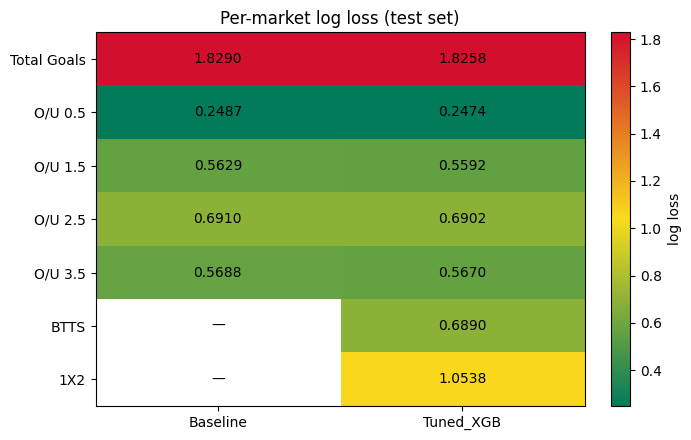

In [53]:
pvt = market_table.pivot(index='market', columns='model', values='logloss')
order = ['Total Goals', 'O/U 0.5', 'O/U 1.5', 'O/U 2.5', 'O/U 3.5', 'BTTS', '1X2']
pvt = pvt.reindex([m for m in order if m in pvt.index])

fig, ax = plt.subplots(figsize=(7, 4.5))
data = pvt.values
brand_div_cmap = LinearSegmentedColormap.from_list('brand_div', [COLOURS[0], COLOURS[1], COLOURS[3]])
im = ax.imshow(data, cmap=brand_div_cmap, aspect='auto')
ax.set_xticks(range(len(pvt.columns))); ax.set_xticklabels(pvt.columns)
ax.set_yticks(range(len(pvt.index)));   ax.set_yticklabels(pvt.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        ax.text(j, i, '—' if np.isnan(v) else f'{v:.4f}', ha='center', va='center', color='black', fontsize=10)
ax.set_title('Per-market log loss (test set)')
plt.colorbar(im, ax=ax, fraction=0.04, label='log loss')
plt.tight_layout()
fig_markets = fig
plt.show()

## 9. Calibration & Reliability

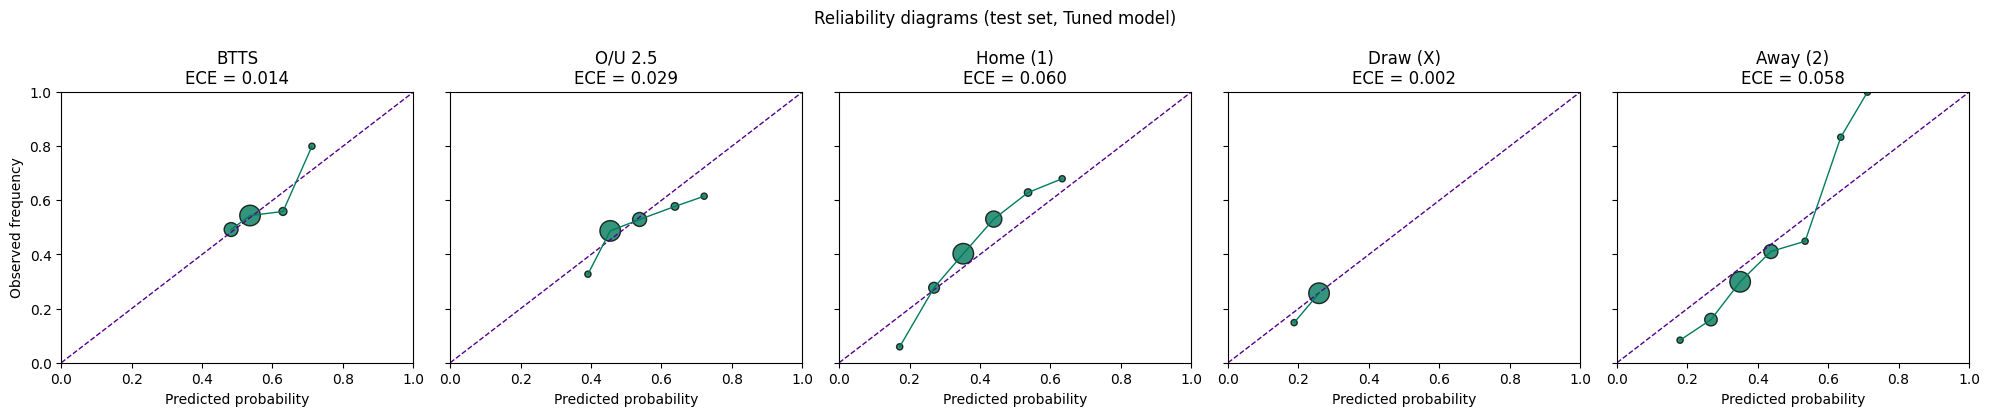

In [54]:
calib_specs = [
    ('BTTS',     M_preds['actual_btts'].values,                              M_preds['p_btts_yes'].values),
    ('O/U 2.5',  M_preds['actual_over_25'].values,                           M_preds['p_over_25'].values),
    ('Home (1)', (M_preds['actual_result'] == 'H').astype(int).values,       M_preds['p_home'].values),
    ('Draw (X)', (M_preds['actual_result'] == 'D').astype(int).values,       M_preds['p_draw'].values),
    ('Away (2)', (M_preds['actual_result'] == 'A').astype(int).values,       M_preds['p_away'].values),
]

calibration_frames = {}
fig, axes = plt.subplots(1, len(calib_specs), figsize=(4 * len(calib_specs), 4.2), sharey=True)
for ax, (name, y, p) in zip(axes, calib_specs):
    bins = reliability_bins(y, p, n_bins=10)
    calibration_frames[name] = bins
    e = ece(y, p)
    ax.plot([0, 1], [0, 1], color=COLOURS[2], ls='--', lw=1)
    valid = bins.dropna(subset=['pred_mean'])
    sizes = (valid['n'] / max(valid['n'].max(), 1) * 220).clip(20)
    ax.scatter(valid['pred_mean'], valid['obs_freq'], s=sizes, color=COLOURS[0], alpha=0.8, edgecolor='k')
    ax.plot(valid['pred_mean'], valid['obs_freq'], color=COLOURS[0], lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{name}\nECE = {e:.3f}')
    ax.set_xlabel('Predicted probability')
axes[0].set_ylabel('Observed frequency')
plt.suptitle('Reliability diagrams (test set, Tuned model)')
plt.tight_layout()
fig_calib = fig
plt.show()

## 10. Segment Breakdown — by League

   season         league     model  n_matches  logloss_mean      mae     rmse  top1_accuracy  within_1_accuracy
2024/2025 Premier League  Baseline        380      1.866629 1.278517 1.616744       0.247368           0.615789
2024/2025 Premier League Tuned_XGB        380      1.872657 1.311808 1.628607       0.247368           0.636842
2024/2025   Championship  Baseline        552      1.809629 1.253888 1.561847       0.264493           0.702899
2024/2025   Championship Tuned_XGB        552      1.803435 1.247306 1.551553       0.262681           0.706522
2024/2025     League One  Baseline        552      1.855932 1.293048 1.623323       0.226449           0.679348
2024/2025     League One Tuned_XGB        552      1.852134 1.280231 1.617439       0.221014           0.679348
2025/2026 Premier League  Baseline        260      1.846922 1.234646 1.579922       0.261538           0.642308
2025/2026 Premier League Tuned_XGB        260      1.846145 1.242917 1.579713       0.253846           0

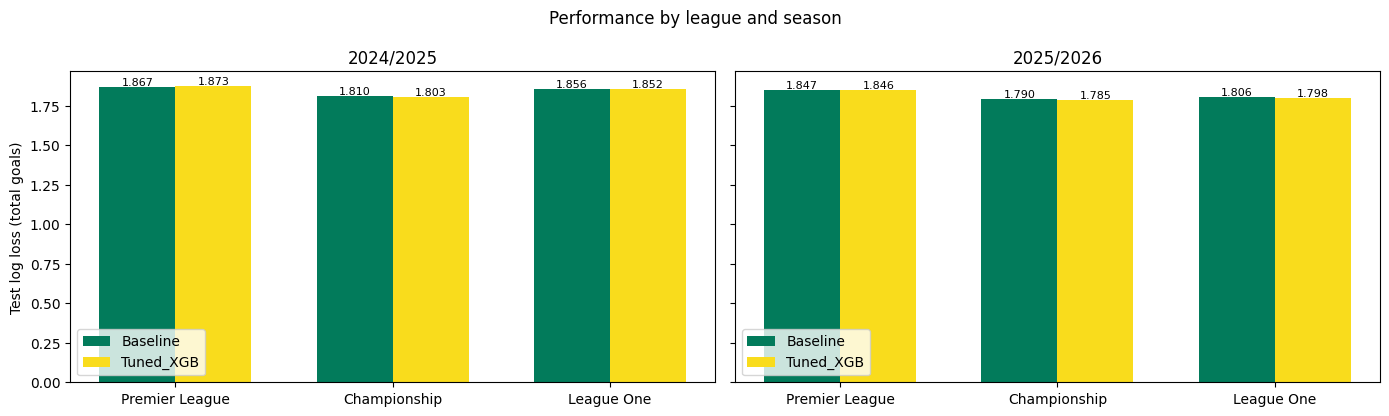

In [55]:
leagues      = ['Premier League', 'Championship', 'League One']
test_seasons = sorted(M_preds['season'].astype(str).unique())

seg_rows = []
for ssn in test_seasons:
    for lg in leagues:
        sub_m = M_preds[(M_preds['season'].astype(str) == ssn) & (M_preds['league'] == lg)]
        sub_b = B_preds[(B_preds['season'].astype(str) == ssn) & (B_preds['league'] == lg)]
        if sub_m.empty:
            continue
        seg_rows.append({'season': ssn, 'league': lg, **_metrics_block(sub_b, 'Baseline')})
        seg_rows.append({'season': ssn, 'league': lg, **_metrics_block(sub_m, 'Tuned_XGB')})
by_league = pd.DataFrame(seg_rows)[['season', 'league', 'model', 'n_matches',
                                    'logloss_mean', 'mae', 'rmse',
                                    'top1_accuracy', 'within_1_accuracy']]
print(by_league.to_string(index=False))

# One subplot per test season; league on x-axis, baseline vs model bars.
fig, axes = plt.subplots(1, len(test_seasons), figsize=(7 * len(test_seasons), 4.2),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, ssn in zip(axes, test_seasons):
    sub = by_league[by_league['season'] == ssn]
    leagues_present = sub['league'].unique().tolist()
    x = np.arange(len(leagues_present)); w = 0.35
    base_ll = [sub[(sub['league'] == l) & (sub['model'] == 'Baseline')]['logloss_mean'].iloc[0]
               for l in leagues_present]
    mod_ll  = [sub[(sub['league'] == l) & (sub['model'] == 'Tuned_XGB')]['logloss_mean'].iloc[0]
               for l in leagues_present]
    ax.bar(x - w/2, base_ll, width=w, label='Baseline',  color=COLOURS[0])
    ax.bar(x + w/2, mod_ll,  width=w, label='Tuned_XGB', color=COLOURS[1])
    for xi, v in zip(x - w/2, base_ll): ax.text(xi, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
    for xi, v in zip(x + w/2, mod_ll):  ax.text(xi, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(leagues_present)
    ax.set_title(ssn)
    ax.legend()
axes[0].set_ylabel('Test log loss (total goals)')
fig.suptitle('Performance by league and season')
plt.tight_layout()
fig_by_league = fig
plt.show()

## 11. Worked Example — One Premier League Fixture

Matrix → prices: scoreline heatmap with implied fair odds (`1/p`) on the most likely scorelines, plus BTTS and O/U 2.5 as prob + odds.

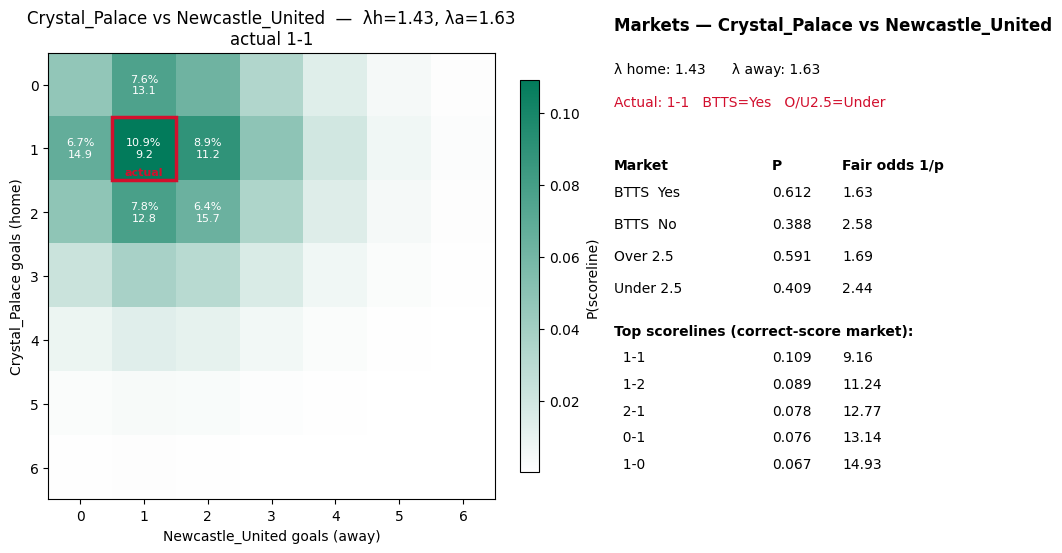

In [56]:
rng = random.Random(RANDOM_SEED)
prem = M_preds.merge(actuals[['home_team', 'away_team']], left_on='match_id', right_index=True, how='left')
prem = prem[prem['league'] == 'Premier League'].reset_index(drop=True)
assert len(prem) > 0, 'No Premier League fixtures in test set.'
pick = prem.iloc[rng.randrange(len(prem))]

lh = float(pick['lambda_home']); la = float(pick['lambda_away'])
M  = scoreline_matrix(lh, la)
act = actuals.loc[pick['match_id']]
hg_act = int(act['home_goals']); ag_act = int(act['away_goals'])
ht = act['home_team']; at = act['away_team']

MAX_SHOW = 6
M_show = M[:MAX_SHOW+1, :MAX_SHOW+1]

fig = plt.figure(figsize=(11, 6.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 1.0])
ax0 = fig.add_subplot(gs[0, 0])
brand_seq_cmap = LinearSegmentedColormap.from_list('brand_seq', ['#ffffff', COLOURS[0]])
im = ax0.imshow(M_show, cmap=brand_seq_cmap, origin='upper')
ax0.set_xticks(range(MAX_SHOW+1)); ax0.set_yticks(range(MAX_SHOW+1))
ax0.set_xlabel(f'{at} goals (away)'); ax0.set_ylabel(f'{ht} goals (home)')
ax0.set_title(f'{ht} vs {at}  —  λh={lh:.2f}, λa={la:.2f}\nactual {hg_act}-{ag_act}')

flat = [(i, j, M_show[i, j]) for i in range(MAX_SHOW+1) for j in range(MAX_SHOW+1)]
flat.sort(key=lambda t: -t[2])
for i, j, p in flat[:6]:
    ax0.text(j, i, f'{p*100:.1f}%\n{1/p:.1f}', ha='center', va='center',
             color='white' if p > M_show.max() * 0.55 else 'black', fontsize=8)
if hg_act <= MAX_SHOW and ag_act <= MAX_SHOW:
    ax0.add_patch(Rectangle((ag_act - 0.5, hg_act - 0.5), 1, 1, fill=False, edgecolor=COLOURS[3], lw=2.5))
    ax0.text(ag_act, hg_act + 0.42, 'actual', color=COLOURS[3], ha='center', fontsize=8, fontweight='bold')
plt.colorbar(im, ax=ax0, fraction=0.04, label='P(scoreline)')

ax1 = fig.add_subplot(gs[0, 1]); ax1.axis('off')
mp = market_probs_from_matrix(M)
lines = [
    ('BTTS  Yes', mp['p_btts_yes']),
    ('BTTS  No',  mp['p_btts_no']),
    ('Over 2.5',  mp['p_over_25']),
    ('Under 2.5', 1 - mp['p_over_25']),
]
actual_btts = 'Yes' if (hg_act >= 1 and ag_act >= 1) else 'No'
actual_ou25 = 'Over' if (hg_act + ag_act) > 2.5 else 'Under'
ax1.text(0.0, 0.96, f'Markets — {ht} vs {at}', fontsize=12, fontweight='bold')
ax1.text(0.0, 0.88, f'λ home: {lh:.2f}      λ away: {la:.2f}', fontsize=10)
ax1.text(0.0, 0.82, f'Actual: {hg_act}-{ag_act}   BTTS={actual_btts}   O/U2.5={actual_ou25}', fontsize=10, color=COLOURS[3])
y = 0.70
ax1.text(0.0, y, 'Market',         fontsize=10, fontweight='bold')
ax1.text(0.45, y, 'P',             fontsize=10, fontweight='bold')
ax1.text(0.65, y, 'Fair odds 1/p', fontsize=10, fontweight='bold')
y -= 0.05
for label, p in lines:
    ax1.text(0.0, y, label, fontsize=10)
    ax1.text(0.45, y, f'{p:.3f}', fontsize=10)
    ax1.text(0.65, y, f'{1/p:.2f}', fontsize=10)
    y -= 0.06
y -= 0.02
ax1.text(0.0, y, 'Top scorelines (correct-score market):', fontsize=10, fontweight='bold'); y -= 0.05
for i, j, p in flat[:5]:
    ax1.text(0.0, y, f'  {i}-{j}', fontsize=10)
    ax1.text(0.45, y, f'{p:.3f}', fontsize=10)
    ax1.text(0.65, y, f'{1/p:.2f}', fontsize=10)
    y -= 0.05
plt.tight_layout()
fig_example = fig
plt.show()

## 12. Save Outputs

In [57]:
test_predictions = M_preds.copy()
test_predictions['pmf_json']    = test_predictions['pmf'].apply(lambda a: json.dumps(list(map(float, a))))
test_predictions['tg_pmf_json'] = test_predictions['tg_pmf'].apply(lambda a: json.dumps(list(map(float, a))))
out_cols = ['match_id', 'season', 'league', 'lambda_home', 'lambda_away', 'expected',
            'total_goals', 'actual_result', 'actual_btts',
            'actual_over_05', 'actual_over_15', 'actual_over_25', 'actual_over_35',
            'p_home', 'p_draw', 'p_away',
            'p_btts_yes', 'p_btts_no',
            'p_over_05', 'p_over_15', 'p_over_25', 'p_over_35',
            'pmf_json', 'tg_pmf_json']
test_predictions[out_cols].to_csv(EVAL_DIR / 'test_predictions.csv', index=False)

market_table[['model', 'market', 'n', 'logloss', 'brier', 'accuracy', 'auc']].to_csv(
    EVAL_DIR / 'test_metrics.csv', index=False)

by_league.to_csv(EVAL_DIR / 'test_metrics_by_league.csv', index=False)

for name, frame in calibration_frames.items():
    safe = name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
    frame.to_csv(EVAL_DIR / f'calibration_{safe}.csv', index=False)

fig_logloss.savefig(EVAL_DIR / 'eval_logloss_compare.png',     dpi=140, bbox_inches='tight')
fig_confusion.savefig(EVAL_DIR / 'eval_confusion_total.png',   dpi=140, bbox_inches='tight')
fig_markets.savefig(EVAL_DIR / 'eval_markets_table.png',       dpi=140, bbox_inches='tight')
fig_calib.savefig(EVAL_DIR / 'eval_calibration_panels.png',    dpi=140, bbox_inches='tight')
fig_by_league.savefig(EVAL_DIR / 'eval_by_league.png',         dpi=140, bbox_inches='tight')
fig_example.savefig(EVAL_DIR / 'eval_prem_fixture_example.png', dpi=140, bbox_inches='tight')

test_total_logloss_model    = float(total_goals_metrics.loc[total_goals_metrics['model'] == 'Tuned_XGB', 'logloss_mean'].iloc[0])
test_total_logloss_baseline = float(total_goals_metrics.loc[total_goals_metrics['model'] == 'Baseline',  'logloss_mean'].iloc[0])

run_config_eval = {
    'selected_features':      SELECTED_FEATS,
    'best_L':                 BEST_L,
    'best_ALPHA':             BEST_ALPHA,
    'best_xgb_params':        BEST_XGB_PARAMS,
    'test_season':            TEST_SEASON,
    'n_test_fixtures':        int(len(M_preds)),
    'nb04_dev_val_logloss':   NB04_VAL_LOGLOSS,
    'test_logloss_model':     test_total_logloss_model,
    'test_logloss_baseline':  test_total_logloss_baseline,
    'dev_to_test_gap':        test_total_logloss_model - NB04_VAL_LOGLOSS,
    'random_seed':            RANDOM_SEED,
    'timestamp':              datetime.datetime.now(datetime.UTC).isoformat(),
}
(EVAL_DIR / 'run_config_eval.json').write_text(json.dumps(run_config_eval, indent=2))

print(f'Saved → {EVAL_DIR}')
for f in sorted(EVAL_DIR.iterdir()):
    if f.is_file():
        print(f'  {f.name}')
print()
print(f'Test fixtures        : {len(M_preds):,}')
print(f'Test logloss (model) : {test_total_logloss_model:.6f}')
print(f'Test logloss (base)  : {test_total_logloss_baseline:.6f}')
print(f'NB04 dev-val ref     : {NB04_VAL_LOGLOSS:.6f}')
print(f'Dev→test gap         : {test_total_logloss_model - NB04_VAL_LOGLOSS:+.6f}')

Saved → ../Outputs/Evaluation
  .DS_Store
  calibration_Away_2.csv
  calibration_BTTS.csv
  calibration_Draw_X.csv
  calibration_Home_1.csv
  calibration_O_U_2.5.csv
  eval_by_league.png
  eval_calibration_panels.png
  eval_confusion_total.png
  eval_logloss_compare.png
  eval_markets_table.png
  eval_prem_fixture_example.png
  run_config_eval.json
  test_metrics.csv
  test_metrics_by_league.csv
  test_predictions.csv

Test fixtures        : 2,488
Test logloss (model) : 1.825755
Test logloss (base)  : 1.828986
NB04 dev-val ref     : 1.840344
Dev→test gap         : -0.014589
